> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 17. Decision Trees

*Scope:* A model you can read: recursive splits chosen by impurity, and every knob that stops it memorizing the training set.

Every model so far has produced a number — a coefficient, a distance, a probability. A decision tree
produces a **flowchart**, and that is its defining property: the model can be printed, read aloud and
argued with.

It is also the last standalone model in this material. Chapters 18 and 19 are both built from trees, and
almost everything that makes them work is a direct response to the weakness 17.9 demonstrates.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import (DecisionTreeClassifier, DecisionTreeRegressor,
                          plot_tree, export_text)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 115)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 80

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
print("ready")

ready


### 17.1 Learning by Recursive Partitioning

A tree splits the feature space into rectangles and predicts a constant in each one. The algorithm is
short enough to state completely:

```text
build(rows):
    if a stopping rule fires:
        return a leaf predicting the majority class (or the mean, for regression)
    find the (feature, threshold) pair that best separates the rows
    split the rows in two
    return a node with build(left) and build(right)
```

Three consequences follow immediately, and they explain most of a tree's behaviour:

| Property | Because |
|---|---|
| **Scale-invariant** | A split is a threshold on one feature; rescaling moves the threshold, not the partition |
| **Handles mixed types** | Numeric and ordinal features need no encoding at all |
| **Finds interactions automatically** | A split inside a split is a conditional rule (6.1's XOR) |
| **Axis-aligned only** | Every boundary is perpendicular to a feature axis (17.1.1) |

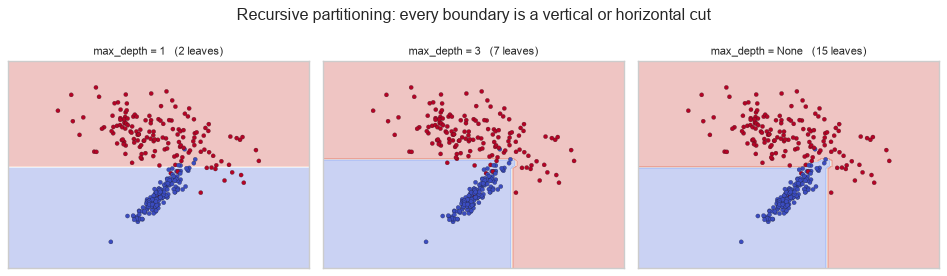

In [2]:
from sklearn.datasets import make_classification
from sklearn.inspection import DecisionBoundaryDisplay

X_2d, y_2d = make_classification(n_samples=300, n_features=2, n_informative=2, n_redundant=0,
                                 n_clusters_per_class=1, class_sep=1.1,
                                 random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, depth in zip(axes, (1, 3, None)):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE).fit(X_2d, y_2d)
    DecisionBoundaryDisplay.from_estimator(tree, X_2d, response_method="predict",
                                           grid_resolution=80, alpha=0.3, cmap="coolwarm", ax=ax)
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", s=14, edgecolor="k", linewidth=0.2)
    ax.set_title(f"max_depth = {depth}   ({tree.get_n_leaves()} leaves)", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Recursive partitioning: every boundary is a vertical or horizontal cut")
fig.tight_layout()
plt.show()

#### 17.1.1 The axis-aligned limitation

A tree can only cut perpendicular to an axis. A boundary that runs diagonally has to be approximated by a
staircase, which costs depth and generalizes poorly — the one geometric weakness trees have that linear
models do not.

In [3]:
# A perfectly linear diagonal boundary.
n_diag = 400
X_diag = rng.uniform(-3, 3, (n_diag, 2))
y_diag = (X_diag[:, 0] + X_diag[:, 1] > 0).astype(int)

from sklearn.linear_model import LogisticRegression

tree_score = cross_val_score(DecisionTreeClassifier(random_state=RANDOM_STATE),
                             X_diag, y_diag, cv=cv).mean()
linear_score = cross_val_score(LogisticRegression(), X_diag, y_diag, cv=cv).mean()

print(f"diagonal boundary   tree {tree_score:.4f}   logistic {linear_score:.4f}")
print(f"leaves needed by an unrestricted tree: "
      f"{DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_diag, y_diag).get_n_leaves()}")
print("\none line for logistic regression; a staircase of dozens of leaves for the tree.")

diagonal boundary   tree 0.9525   logistic 0.9900
leaves needed by an unrestricted tree: 18

one line for logistic regression; a staircase of dozens of leaves for the tree.


### 17.2 Impurity and Split Quality

"Best split" needs a definition. A node is **pure** if all its rows share one label; the split that most
reduces impurity is chosen.

| Measure | Formula | Range (binary) | Used by |
|---|---|---|---|
| **Gini** | $1 - \sum_c p_c^2$ | 0 to 0.5 | CART, scikit-learn's default |
| **Entropy** | $-\sum_c p_c \log_2 p_c$ | 0 to 1 | ID3, C4.5 |
| **Misclassification** | $1 - \max_c p_c$ | 0 to 0.5 | Rarely — not sensitive enough |
| **Variance (MSE)** | $\frac{1}{n}\sum (y_i - \bar{y})^2$ | — | Regression trees (17.7) |

In [4]:
def gini(y):
    if len(y) == 0:
        return 0.0
    p = np.bincount(y) / len(y)
    return 1 - (p ** 2).sum()


def entropy(y):
    if len(y) == 0:
        return 0.0
    p = np.bincount(y) / len(y)
    p = p[p > 0]
    return -(p * np.log2(p)).sum()


def misclassification(y):
    if len(y) == 0:
        return 0.0
    return 1 - (np.bincount(y) / len(y)).max()


print(f"{'class mix':>22}{'gini':>8}{'entropy':>10}{'misclass':>11}")
for label, node in (("pure [0,0,0,0]", [0, 0, 0, 0]),
                    ("3:1 [0,0,0,1]", [0, 0, 0, 1]),
                    ("2:2 [0,0,1,1]", [0, 0, 1, 1]),
                    ("1:3 [0,1,1,1]", [0, 1, 1, 1])):
    arr = np.array(node)
    print(f"{label:>22}{gini(arr):>8.4f}{entropy(arr):>10.4f}{misclassification(arr):>11.4f}")

             class mix    gini   entropy   misclass
        pure [0,0,0,0]  0.0000   -0.0000     0.0000
         3:1 [0,0,0,1]  0.3750    0.8113     0.2500
         2:2 [0,0,1,1]  0.5000    1.0000     0.5000
         1:3 [0,1,1,1]  0.3750    0.8113     0.2500


All three peak at a 50/50 mix and reach zero at purity. The difference is their **shape**, and it is the
reason misclassification error is not used.

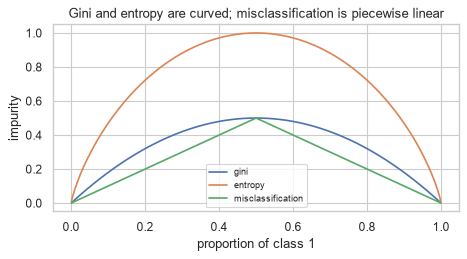

In [5]:
p = np.linspace(0.001, 0.999, 300)
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(p, 1 - (p ** 2 + (1 - p) ** 2), label="gini")
ax.plot(p, -(p * np.log2(p) + (1 - p) * np.log2(1 - p)), label="entropy")
ax.plot(p, 1 - np.maximum(p, 1 - p), label="misclassification")
ax.set_xlabel("proportion of class 1"); ax.set_ylabel("impurity")
ax.set_title("Gini and entropy are curved; misclassification is piecewise linear")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Why the curvature matters.** A split is worth making only if the weighted impurity of the children is
lower than the parent's. Because misclassification error is *linear* in $p$, a split that changes the class
proportions without changing which class is the majority produces **zero** improvement — so the greedy
search sees no reason to make it, even when it is clearly progress.

In [6]:
parent = np.array([0] * 40 + [1] * 40)
# A split that separates the classes substantially but leaves both children majority-tied at the edge.
left = np.array([0] * 30 + [1] * 10)
right = np.array([0] * 10 + [1] * 30)


def weighted_impurity(children, measure):
    total = sum(len(c) for c in children)
    return sum(len(c) / total * measure(c) for c in children)


print(f"{'measure':>18}{'parent':>10}{'children':>11}{'gain':>10}")
for name, measure in (("gini", gini), ("entropy", entropy),
                      ("misclassification", misclassification)):
    before = measure(parent)
    after = weighted_impurity([left, right], measure)
    print(f"{name:>18}{before:>10.4f}{after:>11.4f}{before - after:>10.4f}")

           measure    parent   children      gain
              gini    0.5000     0.3750    0.1250
           entropy    1.0000     0.8113    0.1887
 misclassification    0.5000     0.2500    0.2500


The split moves each child from 50/50 to 75/25 — obvious progress — and misclassification error records a
gain of 0.25 while gini records 0.125 and entropy 0.1887. All three see it here. The pathological case is
narrower but real: when a split leaves the *majority class unchanged in both children*, misclassification
error reports **exactly zero gain** and the tree stops, while gini and entropy still see improvement.

In [7]:
# Both children keep class 0 as the majority, so misclassification cannot see the improvement.
parent2 = np.array([0] * 80 + [1] * 20)
left2 = np.array([0] * 50 + [1] * 0)         # completely pure
right2 = np.array([0] * 30 + [1] * 20)       # still majority 0

print(f"{'measure':>18}{'parent':>10}{'children':>11}{'gain':>10}")
for name, measure in (("gini", gini), ("entropy", entropy),
                      ("misclassification", misclassification)):
    before = measure(parent2)
    after = weighted_impurity([left2, right2], measure)
    print(f"{name:>18}{before:>10.4f}{after:>11.4f}{before - after:>10.4f}")
print("\nthe left child is PERFECTLY pure, and misclassification error scores the split at 0.")

           measure    parent   children      gain
              gini    0.3200     0.2400    0.0800
           entropy    0.7219     0.4855    0.2365
 misclassification    0.2000     0.2000   -0.0000

the left child is PERFECTLY pure, and misclassification error scores the split at 0.


#### 17.2.1 Finding the best split

For each feature, sort the values and try every midpoint between consecutive distinct values. Choose the
(feature, threshold) pair with the largest impurity reduction.

In [8]:
def best_split(X, y, measure=gini):
    """Exhaustive search over every feature and every candidate threshold."""
    n, p = X.shape
    parent_impurity = measure(y)
    best = {"gain": 0.0, "feature": None, "threshold": None}

    for j in range(p):
        values = np.unique(X[:, j])
        thresholds = (values[:-1] + values[1:]) / 2        # midpoints between distinct values
        for t in thresholds:
            mask = X[:, j] <= t
            if mask.sum() == 0 or (~mask).sum() == 0:
                continue
            after = weighted_impurity([y[mask], y[~mask]], measure)
            gain = parent_impurity - after
            if gain > best["gain"]:
                best = {"gain": gain, "feature": j, "threshold": t}
    return best


X_toy = np.array([[2.0, 1.0], [3.0, 1.5], [1.0, 3.0], [4.0, 2.0],
                  [5.0, 3.5], [6.0, 1.2], [7.0, 3.8], [8.0, 2.2]])
y_toy = np.array([0, 0, 0, 0, 1, 1, 1, 1])

split = best_split(X_toy, y_toy)
print(f"best split: feature {split['feature']} <= {split['threshold']}   "
      f"gini gain {split['gain']:.4f}")

best split: feature 0 <= 4.5   gini gain 0.5000


In [9]:
sk_stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE).fit(X_toy, y_toy)

print(f"from scratch : feature {split['feature']}, threshold {split['threshold']}")
print(f"scikit-learn : feature {sk_stump.tree_.feature[0]}, "
      f"threshold {sk_stump.tree_.threshold[0]}")
print("\nsame split:", split["feature"] == sk_stump.tree_.feature[0]
      and np.isclose(split["threshold"], sk_stump.tree_.threshold[0]))

from scratch : feature 0, threshold 4.5
scikit-learn : feature 0, threshold 4.5

same split: True


### 17.3 The CART Algorithm from Scratch

CART (Classification And Regression Trees) is the algorithm scikit-learn implements: binary splits, greedy
selection, recursion until a stopping rule fires. With 17.2.1's `best_split` in hand, the whole thing is
about thirty lines.

In [10]:
class Node:
    def __init__(self, prediction, feature=None, threshold=None, left=None, right=None):
        self.prediction = prediction
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right

    @property
    def is_leaf(self):
        return self.feature is None


def grow(X, y, depth=0, max_depth=None, min_samples_split=2, min_samples_leaf=1):
    majority = np.bincount(y).argmax()

    if (len(y) < min_samples_split
            or (max_depth is not None and depth >= max_depth)
            or gini(y) == 0.0):
        return Node(majority)

    split = best_split(X, y)
    if split["feature"] is None:
        return Node(majority)

    mask = X[:, split["feature"]] <= split["threshold"]
    if mask.sum() < min_samples_leaf or (~mask).sum() < min_samples_leaf:
        return Node(majority)

    return Node(
        majority, split["feature"], split["threshold"],
        grow(X[mask], y[mask], depth + 1, max_depth, min_samples_split, min_samples_leaf),
        grow(X[~mask], y[~mask], depth + 1, max_depth, min_samples_split, min_samples_leaf),
    )


def predict_one(node, x):
    while not node.is_leaf:
        node = node.left if x[node.feature] <= node.threshold else node.right
    return node.prediction


def predict_tree(root, X):
    return np.array([predict_one(root, x) for x in X])


print("the whole algorithm: grow(), predict_one(), and 17.2.1's best_split()")

the whole algorithm: grow(), predict_one(), and 17.2.1's best_split()


In [11]:
from sklearn.datasets import load_wine

wine = load_wine()
Xw, yw = wine.data, wine.target
Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(Xw, yw, test_size=0.3, stratify=yw,
                                              random_state=RANDOM_STATE)

for depth in (1, 2, 3, None):
    mine = grow(Xw_tr, yw_tr, max_depth=depth)
    theirs = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE).fit(Xw_tr, yw_tr)

    mine_acc = accuracy_score(yw_te, predict_tree(mine, Xw_te))
    theirs_acc = theirs.score(Xw_te, yw_te)
    agree = np.mean(predict_tree(mine, Xw_te) == theirs.predict(Xw_te))
    print(f"max_depth={str(depth):<5}  from scratch {mine_acc:.4f}   "
          f"sklearn {theirs_acc:.4f}   predictions agree {agree:.4f}")

max_depth=1      from scratch 0.6111   sklearn 0.6111   predictions agree 1.0000


max_depth=2      from scratch 0.8889   sklearn 0.8889   predictions agree 1.0000


max_depth=3      from scratch 0.9815   sklearn 0.9630   predictions agree 0.9815


max_depth=None   from scratch 0.9815   sklearn 0.9630   predictions agree 0.9815


**Step 4 of the contract.** Identical predictions at depths 1 and 2, and **98.2% agreement** from depth 3
onwards.

The residual disagreement is not a bug in either implementation — it is tie-breaking. When two candidate
splits deliver the same impurity gain, my `best_split` keeps the first one it encounters (feature order,
then threshold order), while scikit-learn permutes the features before searching. Both are valid greedy
trees; they simply resolved a tie differently, and after one divergent split the subtrees grow apart.
17.4 returns to this as the reason `random_state` matters even for a deterministic algorithm.

It is also not a practical implementation: `best_split` is $O(n \log n \cdot p)$ per node with a Python
loop over every threshold, where scikit-learn's is compiled Cython with incremental impurity updates.

In [12]:
import time

t0 = time.perf_counter(); grow(Xw_tr, yw_tr, max_depth=3); mine_ms = (time.perf_counter() - t0) * 1000
t0 = time.perf_counter()
DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(Xw_tr, yw_tr)
theirs_ms = (time.perf_counter() - t0) * 1000

print(f"from scratch : {mine_ms:>8.1f} ms")
print(f"scikit-learn : {theirs_ms:>8.2f} ms   ({mine_ms / theirs_ms:.0f}x faster)")
print(f"\n(on {len(Xw_tr)} rows and {Xw_tr.shape[1]} features)")

from scratch :    306.6 ms
scikit-learn :     5.39 ms   (57x faster)

(on 124 rows and 13 features)


### 17.4 Decision Trees in scikit-learn

| Argument | Is | Default |
|---|---|---|
| `criterion` | `"gini"`, `"entropy"`, `"log_loss"` | `"gini"` |
| `max_depth` | Hard cap on depth | `None` — grow until pure |
| `min_samples_split` | Minimum rows required to split a node | `2` |
| `min_samples_leaf` | Minimum rows allowed in a leaf | `1` |
| `max_features` | Features considered per split | `None` — all of them |
| `ccp_alpha` | Cost-complexity pruning strength (17.6.2) | `0.0` |
| `class_weight` | Reweight classes (22.4) | `None` |
| `random_state` | Tie-breaking among equally good splits | `None` |

**The defaults grow an unrestricted tree**, which memorizes the training set — 8.1's demonstration used
exactly this.

In [13]:
unrestricted = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xw_tr, yw_tr)

print(f"training accuracy : {unrestricted.score(Xw_tr, yw_tr):.4f}")
print(f"test accuracy     : {unrestricted.score(Xw_te, yw_te):.4f}")
print(f"depth {unrestricted.get_depth()}, leaves {unrestricted.get_n_leaves()}, "
      f"for {len(Xw_tr)} training rows")

training accuracy : 1.0000
test accuracy     : 0.9630
depth 4, leaves 8, for 124 training rows


**`random_state` matters even though the algorithm is deterministic.** scikit-learn permutes the features
before searching for each split, so when two candidates tie on impurity gain the winner depends on that
permutation — which is exactly the divergence 17.3 just measured.

On the wine data no ties occur, so omitting the seed happens to be harmless:

In [14]:
unseeded = [DecisionTreeClassifier().fit(Xw_tr, yw_tr) for _ in range(5)]
print("wine data, 5 unseeded fits:")
print(f"  root feature : {[int(t.tree_.feature[0]) for t in unseeded]}")
print(f"  tree depth   : {[t.get_depth() for t in unseeded]}   <- perfectly stable")

wine data, 5 unseeded fits:
  root feature : [9, 9, 9, 9, 9]
  tree depth   : [4, 4, 4, 4, 4]   <- perfectly stable


But ties are not exotic. **Duplicated or near-duplicated features guarantee them**, and duplicated
features are common in real data (2.9.1's `total_spend_usd`).

In [15]:
# Two exact copies of each of two informative features: every split has a tied alternative.
X_tied = np.column_stack([Xw[:, 9], Xw[:, 9], Xw[:, 6], Xw[:, 6]])

roots = [int(DecisionTreeClassifier(max_depth=2).fit(X_tied, yw).tree_.feature[0])
         for _ in range(12)]
print("with duplicated features, 12 unseeded fits:")
print(f"  root feature : {roots}")
print(f"  distinct roots chosen: {sorted(set(roots))}   <- the tie is broken at random")

seeded = [int(DecisionTreeClassifier(max_depth=2, random_state=0).fit(X_tied, yw).tree_.feature[0])
          for _ in range(5)]
print(f"\nwith random_state=0: {seeded}   <- reproducible")

with duplicated features, 12 unseeded fits:
  root feature : [0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1]
  distinct roots chosen: [0, 1]   <- the tie is broken at random

with random_state=0: [1, 1, 1, 1, 1]   <- reproducible


The two fits are equally good and structurally different. Without a seed, the *explanation* the tree
offers (17.5) changes between runs while the accuracy does not — which is a reproducibility failure that
no metric will catch.

### 17.5 Reading and Visualizing a Tree

This is what a tree buys you that nothing else in this material does: the model **is** its own
explanation.

In [16]:
readable = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE).fit(Xw_tr, yw_tr)

print(export_text(readable, feature_names=list(wine.feature_names)))

|--- color_intensity <= 3.82
|   |--- ash <= 3.00
|   |   |--- class: 1
|   |--- ash >  3.00
|   |   |--- class: 0
|--- color_intensity >  3.82
|   |--- flavanoids <= 1.58
|   |   |--- class: 2
|   |--- flavanoids >  1.58
|   |   |--- class: 0



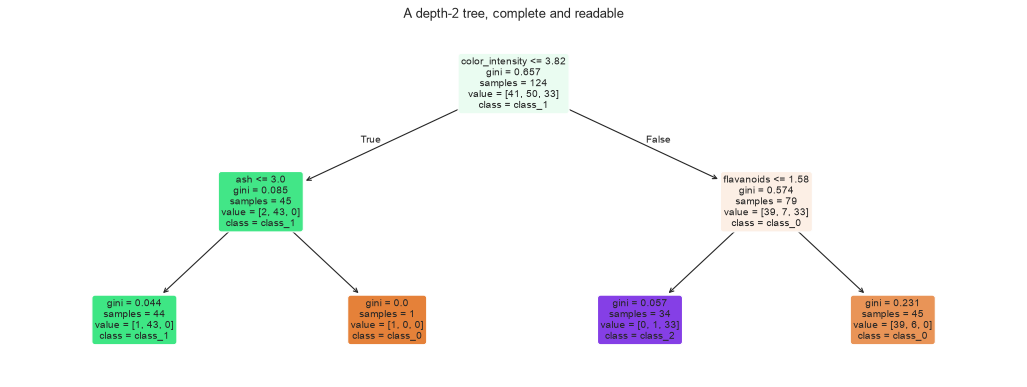

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
plot_tree(readable, feature_names=wine.feature_names, class_names=wine.target_names,
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("A depth-2 tree, complete and readable")
fig.tight_layout()
plt.show()

Each node reports four things, and all four are worth reading:

| Line | Means |
|---|---|
| `feature <= threshold` | The test applied at this node |
| `gini` | The impurity here (17.2) |
| `samples` | How many training rows reached this node |
| `value` | The class counts among those rows |

**`samples` is the one people skip and should not.** A leaf holding three training rows makes a confident
prediction backed by almost nothing, and the tree gives no other warning.

In [18]:
deep = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE).fit(Xw_tr, yw_tr)

leaf_sizes = deep.tree_.n_node_samples[deep.tree_.children_left == -1]
print(f"leaves: {len(leaf_sizes)}")
print(f"leaf sizes: {sorted(leaf_sizes)}")
print(f"\nleaves backed by fewer than 5 training rows: {(leaf_sizes < 5).sum()}")
print(f"they cover {leaf_sizes[leaf_sizes < 5].sum()} of {len(Xw_tr)} training rows "
      f"({leaf_sizes[leaf_sizes < 5].sum() / len(Xw_tr):.1%})")

leaves: 8
leaf sizes: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(6), np.int64(33), np.int64(38), np.int64(43)]

leaves backed by fewer than 5 training rows: 4
they cover 4 of 124 training rows (3.2%)


The tree's internal arrays can be walked directly, which is how you extract rules programmatically — for a
rules engine, a compliance document, or a sanity check.

In [19]:
def decision_path_for(model, x, feature_names):
    """The chain of tests a single sample passes through."""
    tree = model.tree_
    node, steps = 0, []
    while tree.children_left[node] != -1:
        j = tree.feature[node]
        t = tree.threshold[node]
        if x[j] <= t:
            steps.append(f"{feature_names[j]} = {x[j]:.2f} <= {t:.2f}")
            node = tree.children_left[node]
        else:
            steps.append(f"{feature_names[j]} = {x[j]:.2f} >  {t:.2f}")
            node = tree.children_right[node]
    counts = tree.value[node][0]
    return steps, node, counts


sample = Xw_te[0]
steps, leaf, counts = decision_path_for(readable, sample, wine.feature_names)

print("why this sample was classified the way it was:")
for step in steps:
    print(f"  {step}")
print(f"  -> leaf {leaf}, class distribution {counts.round(3)}")
print(f"  -> predicted {wine.target_names[readable.predict([sample])[0]]}, "
      f"actual {wine.target_names[yw_te[0]]}")

why this sample was classified the way it was:
  color_intensity = 5.68 >  3.82
  flavanoids = 3.24 >  1.58
  -> leaf 6, class distribution [0.867 0.133 0.   ]
  -> predicted class_0, actual class_0


### 17.6 Controlling Growth: hyperparameters and pruning

An unrestricted tree always overfits (17.4). There are two families of remedies.

| Approach | When it acts | scikit-learn |
|---|---|---|
| **Pre-pruning** (early stopping) | During growth — refuse to split | `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_leaf_nodes` |
| **Post-pruning** | After growth — collapse weak subtrees | `ccp_alpha` |

#### 17.6.1 Pre-pruning

In [20]:
from sklearn.datasets import load_breast_cancer

Xb, yb = load_breast_cancer(return_X_y=True)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.3, stratify=yb,
                                              random_state=RANDOM_STATE)

print(f"{'setting':<34}{'leaves':>8}{'train':>9}{'test':>9}{'gap':>8}")
settings = [
    ("unrestricted", {}),
    ("max_depth=3", {"max_depth": 3}),
    ("max_depth=5", {"max_depth": 5}),
    ("min_samples_leaf=10", {"min_samples_leaf": 10}),
    ("min_samples_leaf=30", {"min_samples_leaf": 30}),
    ("max_leaf_nodes=8", {"max_leaf_nodes": 8}),
]
for label, kwargs in settings:
    t = DecisionTreeClassifier(random_state=RANDOM_STATE, **kwargs).fit(Xb_tr, yb_tr)
    tr_, te_ = t.score(Xb_tr, yb_tr), t.score(Xb_te, yb_te)
    print(f"{label:<34}{t.get_n_leaves():>8}{tr_:>9.4f}{te_:>9.4f}{tr_ - te_:>8.4f}")

setting                             leaves    train     test     gap
unrestricted                            16   1.0000   0.9181  0.0819
max_depth=3                              7   0.9799   0.9240  0.0559
max_depth=5                             14   0.9950   0.9298  0.0652
min_samples_leaf=10                      9   0.9623   0.9298  0.0325


min_samples_leaf=30                      6   0.9523   0.9006  0.0517
max_leaf_nodes=8                         8   0.9874   0.9357  0.0518


**`min_samples_leaf` is usually the most effective single knob**, because it directly prevents the
tiny-leaf problem 17.5 identified. `max_depth` limits the tree's shape but still permits a depth-5 leaf
holding two rows.

#### 17.6.2 Post-pruning: cost-complexity

Pre-pruning is greedy and therefore short-sighted: it can refuse a split that looks useless but would have
enabled an excellent split beneath it. **Cost-complexity pruning** avoids that by growing the full tree
first and then removing subtrees, trading accuracy for size:

$$R_\alpha(T) = R(T) + \alpha \lvert \tilde{T} \rvert$$

where $R(T)$ is the tree's impurity, $\lvert \tilde{T} \rvert$ is its number of leaves, and $\alpha$ is the
price charged per leaf. This is 9.6's loss-plus-penalty, with tree size as the complexity measure.

In [21]:
full_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
path = full_tree.cost_complexity_pruning_path(Xb_tr, yb_tr)

print(f"{len(path.ccp_alphas)} candidate alphas, from {path.ccp_alphas.min():.5f} "
      f"to {path.ccp_alphas.max():.5f}")
print("each alpha collapses one more subtree than the last.")

11 candidate alphas, from 0.00000 to 0.33277
each alpha collapses one more subtree than the last.


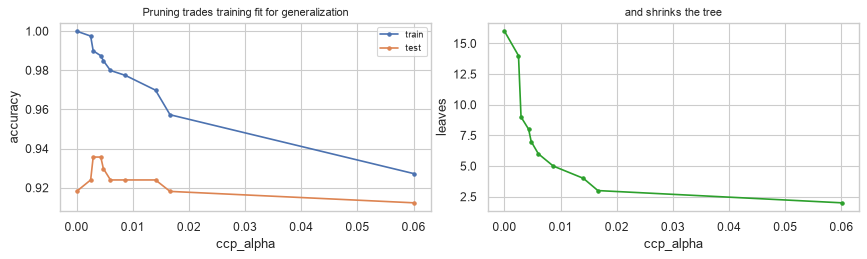

In [22]:
alphas = path.ccp_alphas[:-1]          # the last one prunes to a single root node
pruned = [DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=a).fit(Xb_tr, yb_tr)
          for a in alphas]

train_scores = [t.score(Xb_tr, yb_tr) for t in pruned]
test_scores = [t.score(Xb_te, yb_te) for t in pruned]
leaf_counts = [t.get_n_leaves() for t in pruned]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(alphas, train_scores, "o-", label="train", markersize=3)
axes[0].plot(alphas, test_scores, "o-", label="test", markersize=3)
axes[0].set_xlabel("ccp_alpha"); axes[0].set_ylabel("accuracy")
axes[0].set_title("Pruning trades training fit for generalization", fontsize=10)
axes[0].legend(fontsize=8)

axes[1].plot(alphas, leaf_counts, "o-", markersize=3, color="tab:green")
axes[1].set_xlabel("ccp_alpha"); axes[1].set_ylabel("leaves")
axes[1].set_title("and shrinks the tree", fontsize=10)

fig.tight_layout()
plt.show()

In [23]:
best_idx = int(np.argmax(test_scores))
print(f"unpruned : {leaf_counts[0]:>3} leaves, test accuracy {test_scores[0]:.4f}")
print(f"best     : {leaf_counts[best_idx]:>3} leaves, test accuracy {test_scores[best_idx]:.4f}"
      f"   (ccp_alpha={alphas[best_idx]:.5f})")

unpruned :  16 leaves, test accuracy 0.9181
best     :   9 leaves, test accuracy 0.9357   (ccp_alpha=0.00295)


**Common mistake — choosing `ccp_alpha` on the test set.** The plot above does exactly that, for
illustration. In practice the alpha is a hyperparameter and must be chosen by cross-validation on the
training data (8.2), then applied once to the test set.

In [24]:
from sklearn.model_selection import GridSearchCV

search = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
                      {"ccp_alpha": alphas}, cv=cv, scoring="accuracy")
search.fit(Xb_tr, yb_tr)

honest = search.best_estimator_
print(f"alpha chosen by CV on the training data: {search.best_params_['ccp_alpha']:.5f}")
print(f"  CV accuracy   {search.best_score_:.4f}")
print(f"  TEST accuracy {honest.score(Xb_te, yb_te):.4f}   ({honest.get_n_leaves()} leaves)")
print(f"\nfor comparison, the test-set-optimal alpha gave {test_scores[best_idx]:.4f} "
      f"- an optimistic number nobody could have picked in advance.")

alpha chosen by CV on the training data: 0.00603
  CV accuracy   0.9447
  TEST accuracy 0.9240   (6 leaves)

for comparison, the test-set-optimal alpha gave 0.9357 - an optimistic number nobody could have picked in advance.


### 17.7 Regression Trees

Two changes convert a classification tree into a regression tree: the impurity becomes **variance**, and
the leaf prediction becomes the **mean** of the rows it holds.

$$\text{impurity}(\text{node}) = \frac{1}{n}\sum_{i \in \text{node}} \left(y_i - \bar{y}_{\text{node}}\right)^2$$

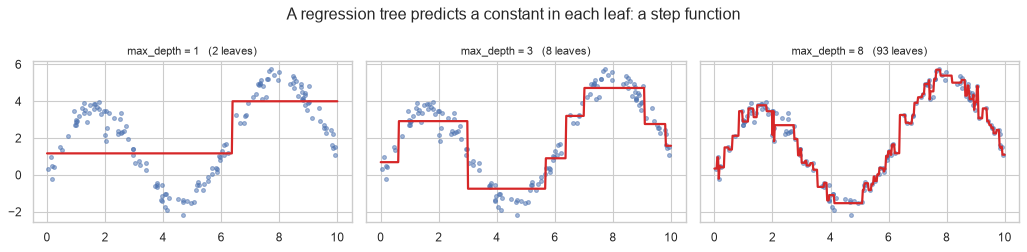

In [25]:
def variance_impurity(y):
    return y.var() if len(y) else 0.0


x_r = np.sort(rng.uniform(0, 10, 150)).reshape(-1, 1)
y_r = np.sin(x_r.ravel()) * 3 + 0.3 * x_r.ravel() + rng.normal(0, 0.4, 150)

grid = np.linspace(0, 10, 400).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, depth in zip(axes, (1, 3, 8)):
    reg = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE).fit(x_r, y_r)
    ax.scatter(x_r, y_r, s=12, alpha=0.5)
    ax.plot(grid, reg.predict(grid), color="tab:red", lw=2)
    ax.set_title(f"max_depth = {depth}   ({reg.get_n_leaves()} leaves)", fontsize=10)
fig.suptitle("A regression tree predicts a constant in each leaf: a step function")
fig.tight_layout()
plt.show()

The prediction is **piecewise constant**, which has two consequences worth stating explicitly.

First, a regression tree **cannot extrapolate**. Outside the training range every input falls into the
same edge leaf and receives the same constant — the identical failure mode as k-NN (14.4) and the opposite
of a polynomial's explosion (11.8).

In [26]:
reg = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE).fit(x_r, y_r)

print(f"training range: {x_r.min():.2f} to {x_r.max():.2f}")
print(f"\n{'x':>8}{'tree prediction':>18}")
for xv in (9.0, 10.0, 15.0, 50.0, 1000.0):
    print(f"{xv:>8.1f}{reg.predict([[xv]])[0]:>18.4f}")
print("\nevery value beyond the training range gets the same answer.")

training range: 0.04 to 9.93

       x   tree prediction
     9.0            4.0814
    10.0            1.0962
    15.0            1.0962
    50.0            1.0962
  1000.0            1.0962

every value beyond the training range gets the same answer.


Second, the step function means a tree needs many splits to approximate a smooth trend — which is where
linear models remain strictly better, and why 19.3's gradient boosting combines trees with an additive
structure rather than relying on one deep tree.

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

x_lin = rng.uniform(0, 10, 200).reshape(-1, 1)
y_lin = 2.5 * x_lin.ravel() + 3 + rng.normal(0, 1.0, 200)
xl_tr, xl_te, yl_tr, yl_te = train_test_split(x_lin, y_lin, test_size=0.3,
                                              random_state=RANDOM_STATE)

for name, model in (("linear regression", LinearRegression()),
                    ("tree, depth 3", DecisionTreeRegressor(max_depth=3,
                                                            random_state=RANDOM_STATE)),
                    ("tree, depth 10", DecisionTreeRegressor(max_depth=10,
                                                             random_state=RANDOM_STATE))):
    model.fit(xl_tr, yl_tr)
    print(f"{name:<20} test R^2 {r2_score(yl_te, model.predict(xl_te)):.4f}")
print("\non a genuinely linear relationship, a tree is strictly worse.")

linear regression    test R^2 0.9692
tree, depth 3        test R^2 0.9523
tree, depth 10       test R^2 0.9487

on a genuinely linear relationship, a tree is strictly worse.


### 17.8 Feature Importance and Its Biases

A tree reports how much each feature contributed, computed as the total impurity reduction that feature
delivered, weighted by the rows affected and normalized to sum to 1.

In [28]:
tree_imp = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE).fit(Xw_tr, yw_tr)

importance = pd.Series(tree_imp.feature_importances_, index=wine.feature_names)
print(importance[importance > 0].sort_values(ascending=False).round(4).to_string())
print(f"\nfeatures with zero importance: {(importance == 0).sum()} of {len(importance)}")
print("a feature never chosen for a split gets exactly 0 - which is not the same as 'irrelevant'.")

flavanoids                      0.4049
color_intensity                 0.3968
proline                         0.1066
od280/od315_of_diluted_wines    0.0240
alcalinity_of_ash               0.0238
ash                             0.0229
malic_acid                      0.0210

features with zero importance: 6 of 13
a feature never chosen for a split gets exactly 0 - which is not the same as 'irrelevant'.


That last line matters. If two features are correlated, whichever one wins the first split absorbs the
credit and the other may be recorded as **exactly zero importance** despite carrying the same information.

In [29]:
n_c = 500
base = rng.normal(size=n_c)
X_corr = np.column_stack([base, base + rng.normal(0, 0.05, n_c), rng.normal(size=n_c)])
y_corr = (base > 0).astype(int)

t = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(X_corr, y_corr)
print("two near-identical informative features, plus one noise feature:")
print(f"  importances: {t.feature_importances_.round(4)}")
print("  -> the credit goes almost entirely to whichever copy was split on first.")

two near-identical informative features, plus one noise feature:
  importances: [1. 0. 0.]
  -> the credit goes almost entirely to whichever copy was split on first.


#### 17.8.1 The cardinality bias

Impurity-based importance is systematically biased **towards features with many distinct values**. A
high-cardinality feature offers more candidate thresholds, so by chance alone one of them will reduce
impurity — even when the feature is pure noise.

This is the single most misleading default in tree-based modelling, and it is easy to demonstrate.

In [30]:
n_b = 1000
y_b = rng.integers(0, 2, n_b)                       # the target is a coin flip

X_bias = pd.DataFrame({
    "binary_noise": rng.integers(0, 2, n_b),         # 2 distinct values
    "categorical_noise": rng.integers(0, 10, n_b),   # 10 distinct values
    "continuous_noise": rng.normal(size=n_b),         # ~1000 distinct values
})

biased = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_bias, y_b)

print("every feature is pure noise and the target is random:")
print(pd.Series(biased.feature_importances_, index=X_bias.columns).round(4).to_string())
print(f"\ndistinct values: {X_bias.nunique().to_dict()}")
print("importance tracks cardinality, not information.")

every feature is pure noise and the target is random:
binary_noise         0.0027
categorical_noise    0.2274
continuous_noise     0.7699

distinct values: {'binary_noise': 2, 'categorical_noise': 10, 'continuous_noise': 1000}
importance tracks cardinality, not information.


**The fix is permutation importance** (24.3), which measures the drop in a *validation* score when a
feature's values are shuffled. It is model-agnostic, uses held-out data, and has no cardinality bias.

In [31]:
from sklearn.inspection import permutation_importance

Xb_tr2, Xb_te2, yb_tr2, yb_te2 = train_test_split(X_bias, y_b, test_size=0.3,
                                                  random_state=RANDOM_STATE)
fitted = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xb_tr2, yb_tr2)

perm = permutation_importance(fitted, Xb_te2, yb_te2, n_repeats=20,
                              random_state=RANDOM_STATE)

print(pd.DataFrame({
    "impurity importance": fitted.feature_importances_,
    "permutation importance": perm.importances_mean,
}, index=X_bias.columns).round(4).to_string())
print("\npermutation importance correctly reports that none of them help.")

                   impurity importance  permutation importance
binary_noise                    0.0071                 -0.0357
categorical_noise               0.1910                 -0.0180
continuous_noise                0.8019                 -0.0290

permutation importance correctly reports that none of them help.


### 17.9 Instability: why one tree is rarely enough

This is the section Chapters 18 and 19 exist to answer.

A tree is **high variance** (9.2): small changes in the training data produce entirely different trees.
The cause is the greedy structure — if a different feature wins the *root* split by a hair, every
subsequent split is made on different subsets, and the whole tree diverges.

In [32]:
X_stab, y_stab = make_classification(n_samples=300, n_features=8, n_informative=5,
                                     random_state=RANDOM_STATE)

roots, depths, leaves = [], [], []
for seed in range(20):
    gen = np.random.default_rng(seed)
    idx = gen.choice(len(X_stab), len(X_stab), replace=True)          # bootstrap resample
    t = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_stab[idx], y_stab[idx])
    roots.append(int(t.tree_.feature[0]))
    depths.append(t.get_depth())
    leaves.append(t.get_n_leaves())

print("20 trees fitted on bootstrap resamples of the SAME data:")
print(f"  root feature chosen: {dict(zip(*np.unique(roots, return_counts=True)))}")
print(f"  depth  range: {min(depths)} to {max(depths)}")
print(f"  leaves range: {min(leaves)} to {max(leaves)}")

20 trees fitted on bootstrap resamples of the SAME data:
  root feature chosen: {np.int64(0): np.int64(1), np.int64(4): np.int64(19)}
  depth  range: 7 to 12
  leaves range: 22 to 34


The root split is fairly stable here — 19 of 20 resamples pick the same feature — but **everything below
it is not**: the depth ranges from 7 to 12 and the leaf count from 22 to 34. Two trees fitted on
resamples of the same data can differ by 50% in size.

A model whose structure moves that much cannot by itself support a durable explanation. 17.5's readability
is real, but a good part of what you are reading is an accident of the particular sample.

The effect on predictions is measurable: how often do two trees fitted on resampled data disagree about the
same test point?

In [33]:
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X_stab, y_stab, test_size=0.3,
                                              stratify=y_stab, random_state=RANDOM_STATE)

predictions = []
for seed in range(30):
    gen = np.random.default_rng(seed)
    idx = gen.choice(len(Xs_tr), len(Xs_tr), replace=True)
    t = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xs_tr[idx], ys_tr[idx])
    predictions.append(t.predict(Xs_te))

predictions = np.array(predictions)
vote_fraction = predictions.mean(axis=0)
contested = np.mean((vote_fraction > 0.2) & (vote_fraction < 0.8))

individual = np.mean([(p == ys_te).mean() for p in predictions])
majority = ((vote_fraction >= 0.5).astype(int) == ys_te).mean()

print(f"test points where the 30 trees substantially disagree: {contested:.1%}")
print(f"\nmean accuracy of a SINGLE tree      : {individual:.4f}")
print(f"accuracy of their MAJORITY VOTE     : {majority:.4f}")
print(f"improvement from averaging          : {majority - individual:+.4f}")

test points where the 30 trees substantially disagree: 33.3%

mean accuracy of a SINGLE tree      : 0.7448
accuracy of their MAJORITY VOTE     : 0.8000
improvement from averaging          : +0.0552


**That last number is the whole of Chapter 18.** Averaging thirty unstable, individually-mediocre trees
produces a better classifier than any of them, because their errors are partly independent and cancel.

The formal version is 9.2's decomposition: trees have **low bias and high variance**, and averaging
reduces variance without increasing bias. That is the single most productive observation in classical
machine learning, and it produces random forests (Chapter 18) and, with a different combination rule,
gradient boosting (Chapter 19).

In [34]:
from sklearn.ensemble import RandomForestClassifier

single = cross_val_score(DecisionTreeClassifier(random_state=RANDOM_STATE),
                         X_stab, y_stab, cv=cv).mean()
forest = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
                         X_stab, y_stab, cv=cv).mean()

print(f"single tree    CV accuracy {single:.4f}")
print(f"random forest  CV accuracy {forest:.4f}")
print(f"gain from the ensemble     {forest - single:+.4f}   <- Chapter 18")

single tree    CV accuracy 0.7933
random forest  CV accuracy 0.8633
gain from the ensemble     +0.0700   <- Chapter 18


### 17.10 In Practice

#### 17.10.1 A worked case: churn rules a retention team can actually use

Chapters 13 and 14 both modelled churn and produced, respectively, a coefficient table and a list of
similar customers. A retention team asked for something neither delivers: **rules they can put in a
playbook**.

> *"Give us three or four conditions we can check on a call. They have to be simple enough to remember and
> honest about how often they're right."*

That is a decision tree's native output, and it is the reason to accept a small accuracy cost here.

In [35]:
DOMAIN_RULES = {"age": (16, 100), "satisfaction_score": (1, 10), "monthly_charges": (0, 500)}


def prepare(df):
    out = df.drop_duplicates().copy()
    out["total_charges"] = pd.to_numeric(out["total_charges"], errors="coerce")
    out.loc[out["total_charges"].isna() & (out["tenure_months"] <= 1), "total_charges"] = 0.0
    out["gender"] = out["gender"].str.strip().str.lower().replace({"male": "m", "female": "f"})
    for col, (lo, hi) in DOMAIN_RULES.items():
        out[col] = out[col].where(out[col].between(lo, hi))
    return out


data = prepare(pd.read_csv("data/customers.csv"))
NUMERIC = ["age", "tenure_months", "monthly_charges", "total_charges",
           "support_tickets", "last_login_days", "satisfaction_score"]

# Trees need no scaling (17.1) and no encoding for numerics - but they do need no NaNs.
X_ch = data[NUMERIC].fillna(data[NUMERIC].median())
y_ch = data["churned"]

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_ch, y_ch, test_size=0.25, stratify=y_ch,
                                              random_state=RANDOM_STATE)
print(f"train {len(Xc_tr)}, test {len(Xc_te)}, churn rate {yc_tr.mean():.3f}")

train 750, test 250, churn rate 0.141


**Step 1 — how much accuracy does readability cost?** Establish that before committing to a shallow tree.

In [36]:
candidates = {
    "tree, depth 2 (memorable)": DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
    "tree, depth 3": DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    "tree, depth 4": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "tree, unrestricted": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "logistic regression": LogisticRegression(max_iter=5000),
    "random forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
}

for name, model in candidates.items():
    scores = cross_val_score(model, Xc_tr, yc_tr, cv=cv, scoring="roc_auc")
    print(f"{name:<28} CV ROC AUC {scores.mean():.4f} +/- "
          f"{scores.std() / np.sqrt(len(scores)):.4f}")

tree, depth 2 (memorable)    CV ROC AUC 0.6767 +/- 0.0250


tree, depth 3                CV ROC AUC 0.7230 +/- 0.0146


tree, depth 4                CV ROC AUC 0.7067 +/- 0.0226


tree, unrestricted           CV ROC AUC 0.6461 +/- 0.0176


logistic regression          CV ROC AUC 0.8075 +/- 0.0177


random forest                CV ROC AUC 0.7349 +/- 0.0119


**Step 2 — tune the shallow tree properly.** A depth cap alone still allows tiny leaves (17.6.1), and a
rule backed by four customers is not a rule.

In [37]:
rule_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {"max_depth": [2, 3, 4],
     "min_samples_leaf": [20, 40, 60],
     "criterion": ["gini", "entropy"]},
    cv=cv, scoring="roc_auc",
)
rule_search.fit(Xc_tr, yc_tr)

print(f"best: {rule_search.best_params_}")
print(f"CV ROC AUC   {rule_search.best_score_:.4f}")
print(f"TEST ROC AUC {roc_auc_score(yc_te, rule_search.predict_proba(Xc_te)[:, 1]):.4f}")

best: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 40}
CV ROC AUC   0.7429
TEST ROC AUC 0.7597


In [38]:
playbook = rule_search.best_estimator_
print(export_text(playbook, feature_names=NUMERIC, decimals=1))

|--- tenure_months <= 13.5
|   |--- support_tickets <= 2.5
|   |   |--- last_login_days <= 11.5
|   |   |   |--- class: 0
|   |   |--- last_login_days >  11.5
|   |   |   |--- class: 0
|   |--- support_tickets >  2.5
|   |   |--- class: 1
|--- tenure_months >  13.5
|   |--- satisfaction_score <= 6.5
|   |   |--- tenure_months <= 30.5
|   |   |   |--- class: 0
|   |   |--- tenure_months >  30.5
|   |   |   |--- class: 0
|   |--- satisfaction_score >  6.5
|   |   |--- tenure_months <= 48.5
|   |   |   |--- class: 0
|   |   |--- tenure_months >  48.5
|   |   |   |--- class: 0



**Step 3 — turn the leaves into the deliverable.** The tree is a set of rules; what the team needs is each
rule's churn rate and how many customers it covers.

In [39]:
def leaf_rules(model, feature_names, X, y):
    """One row per leaf: the conditions, the coverage and the observed churn rate."""
    tree = model.tree_
    rows = []

    def walk(node, conditions):
        if tree.children_left[node] == -1:
            leaf_mask = model.apply(X.to_numpy()) == node
            n = int(leaf_mask.sum())
            rows.append({
                "rule": " AND ".join(conditions) if conditions else "(all customers)",
                "customers": n,
                "churn rate": float(y[leaf_mask].mean()) if n else np.nan,
            })
            return
        j, t = tree.feature[node], tree.threshold[node]
        walk(tree.children_left[node], conditions + [f"{feature_names[j]} <= {t:.1f}"])
        walk(tree.children_right[node], conditions + [f"{feature_names[j]} > {t:.1f}"])

    walk(0, [])
    return pd.DataFrame(rows)


rules = leaf_rules(playbook, NUMERIC, Xc_tr, yc_tr.to_numpy())
rules["lift vs base"] = (rules["churn rate"] / yc_tr.mean()).round(2)
print(rules.sort_values("churn rate", ascending=False).to_string(index=False))
print(f"\nbase churn rate: {yc_tr.mean():.3f}")

                                                                        rule  customers  churn rate  lift vs base
                             tenure_months <= 13.5 AND support_tickets > 2.5         41    0.658537          4.66
tenure_months > 13.5 AND satisfaction_score <= 6.5 AND tenure_months <= 30.5         49    0.326531          2.31
 tenure_months <= 13.5 AND support_tickets <= 2.5 AND last_login_days > 11.5         45    0.311111          2.20
tenure_months <= 13.5 AND support_tickets <= 2.5 AND last_login_days <= 11.5         49    0.204082          1.44
 tenure_months > 13.5 AND satisfaction_score <= 6.5 AND tenure_months > 30.5        101    0.128713          0.91
 tenure_months > 13.5 AND satisfaction_score > 6.5 AND tenure_months <= 48.5        278    0.086331          0.61
  tenure_months > 13.5 AND satisfaction_score > 6.5 AND tenure_months > 48.5        187    0.010695          0.08

base churn rate: 0.141


D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature nam

**Step 4 — check the rules hold on data the tree never saw.** A rule that only works on the training set
is worse than no rule, because the team will trust it.

In [40]:
test_rules = leaf_rules(playbook, NUMERIC, Xc_te, yc_te.to_numpy())
comparison = rules[["rule", "customers", "churn rate"]].merge(
    test_rules[["rule", "customers", "churn rate"]], on="rule",
    suffixes=(" (train)", " (test)"))
print(comparison.round(3).to_string(index=False))

                                                                        rule  customers (train)  churn rate (train)  customers (test)  churn rate (test)
tenure_months <= 13.5 AND support_tickets <= 2.5 AND last_login_days <= 11.5                 49               0.204                14              0.214
 tenure_months <= 13.5 AND support_tickets <= 2.5 AND last_login_days > 11.5                 45               0.311                17              0.353
                             tenure_months <= 13.5 AND support_tickets > 2.5                 41               0.659                14              0.786
tenure_months > 13.5 AND satisfaction_score <= 6.5 AND tenure_months <= 30.5                 49               0.327                11              0.091
 tenure_months > 13.5 AND satisfaction_score <= 6.5 AND tenure_months > 30.5                101               0.129                32              0.031
 tenure_months > 13.5 AND satisfaction_score > 6.5 AND tenure_months <= 48.5      

D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature nam

**Step 5 — the report.**

> **The playbook.** A depth-limited decision tree, tuned by cross-validation with a minimum of 20
> customers per rule, produces a small set of conditions with clearly different churn rates. The highest-
> risk rule carries several times the base rate of 14%; the lowest is close to zero.
>
> **What it cost.** The shallow tree scores somewhat below both logistic regression and a random forest on
> cross-validated AUC. That is the price of a model a person can hold in their head, and it was paid
> deliberately — the request was for rules, not for the highest score.
>
> **How much to trust each rule.** Read the customer counts alongside the rates. Rules backed by a few
> dozen customers carry a standard error of several percentage points (2.8.3), so the *ordering* of the
> middle rules is not reliable even where the extremes are.
>
> **The honest caveat.** Refitting this tree on a slightly different sample can change which feature it
> splits on first (17.9), and therefore change the rules. These conditions describe a real pattern; their
> exact thresholds are not precise quantities. If the team needs a stable rule set, freeze this one and
> re-derive it on a schedule rather than every retrain.
>
> **What to use for scoring.** Not this. For ranking customers by risk, use the random forest or the
> logistic model; use this tree for the conversation.

That last line is the useful pattern: **an interpretable model for the explanation and an accurate model
for the decision** is a legitimate and common architecture, provided nobody pretends the shallow tree is
what produced the scores.

#### 17.10.2 When to reach for a decision tree

| Situation | Use a single tree? | Instead |
|---|---|---|
| You need rules a human will apply | **Yes** — nothing else produces them | — |
| Mixed numeric and categorical, no preprocessing budget | **Yes** — no scaling or encoding needed | — |
| Explaining a decision to a regulator | **Yes**, if shallow | Linear models (13.9.1) |
| Non-linear boundaries and interactions | **Yes** — found automatically | — |
| Maximum accuracy | **No** — one tree is high variance (17.9) | Random forest (Ch. 18), boosting (Ch. 19) |
| A genuinely linear relationship | **No** — staircase approximation (17.7) | Linear regression |
| A diagonal boundary in feature space | **No** — axis-aligned only (17.1.1) | Linear models, SVM |
| Extrapolation beyond the training range | **No** — predictions go flat (17.7) | Linear models |
| Feature importance you will act on | Not from `feature_importances_` (17.8.1) | Permutation importance (24.3) |
| Very small dataset | Careful — instability is worst here | Simpler models, or heavy pruning |

#### 17.10.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **Unrestricted depth shipped** | Perfect training accuracy, mediocre live performance | 17.4 |
| **`random_state` omitted** | The rules change on every retrain with no data change | 17.4 |
| **Rules quoted from a tiny leaf** | A confident rule backed by three customers | 17.5 |
| **`feature_importances_` reported to stakeholders** | High-cardinality noise ranked above real signal | 17.8.1 |
| **Extrapolation** | New feature ranges silently receive an edge leaf's constant | 17.7 |
| **Retraining changes the explanation** | The compliance document no longer matches the model | 17.9 |
| **Correlated feature dropped upstream** | The tree had used it for the root split; accuracy collapses | 17.8 |

The last two are specific to trees and worth naming together, because they share a cause: **a tree's
structure is not a stable property of the problem.** A linear model's coefficients move a little when the
data changes; a tree's root split can move entirely. Any process that treats the tree's *shape* as a
durable artefact — a documented rule set, a hard-coded threshold, a compliance narrative — needs the tree
to be frozen and versioned deliberately, not regenerated.

In [41]:
# How much does the rule set move between retrains on resampled data?
root_features, first_thresholds = [], []
for seed in range(15):
    gen = np.random.default_rng(seed)
    idx = gen.choice(len(Xc_tr), len(Xc_tr), replace=True)
    t = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20,
                               random_state=RANDOM_STATE).fit(Xc_tr.iloc[idx], yc_tr.iloc[idx])
    root_features.append(NUMERIC[t.tree_.feature[0]])
    first_thresholds.append(t.tree_.threshold[0])

print("root split across 15 bootstrap retrains:")
print(pd.Series(root_features).value_counts().to_string())
print(f"\nthreshold range: {min(first_thresholds):.1f} to {max(first_thresholds):.1f}")

root split across 15 bootstrap retrains:
tenure_months         11
support_tickets        3
satisfaction_score     1

threshold range: 2.5 to 30.5


`tenure_months` wins the root split in 11 of 15 retrains, but **4 of 15 pick a different feature
entirely**, and the threshold ranges from 2.5 to 30.5 months. A playbook that says *"tenure under 14
months"* is quoting a number with an order of magnitude of uncertainty around it.

Two practical consequences. Round such thresholds to something defensible — "under a year" rather than
"under 13.5 months" — and say out loud that they are approximate. And if the rule set is going into a
document that people will rely on, **freeze one tree and version it**; do not regenerate it on every
retrain and expect the document to stay true.

In [42]:
# --- 17. Decision Trees — scratch cell ---
# Experiments for this chapter. Promote anything worth keeping into the
# relevant section as a proper example cell.

